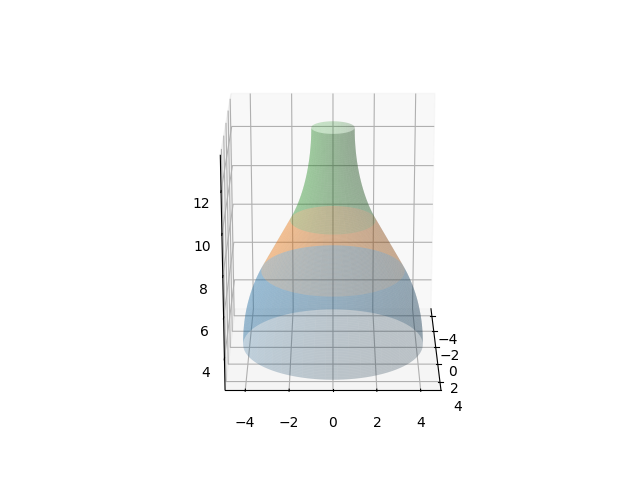

Number of rows:  19
Stitch width:  0.6
Stitch height:  0.6


u,z,s,Circumference,Row,Stitch count
2.67304,2.68244,0,27.0176,0,45
2.9738,3.28396,0.602086,26.8768,1,45
3.27456,3.88548,1.20734,26.4667,2,44
3.57532,4.487,1.81914,25.7746,3,43
3.85729,5.05093,2.40232,24.8487,4,41
4.14865,5.63365,3.01971,23.5762,5,39
4.42121,6.17878,3.61731,22.0467,6,37
4.93171,6.70926,4.22064,20.2444,7,34
5.59456,7.21744,4.80103,18.4829,8,31
6.29055,7.75103,5.41043,16.6333,9,28


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib ipympl
from tabulate import tabulate

#Rounding
dp = 2

#Bottle parameters
p = 1
a = 3.4
b = 4
theta = .7
phi = .45
e = 4.3
d = np.sqrt(e*(e-p)/2)
H = (a+b+(a-b)*np.cos(theta))/np.sin(theta) + d
c = ((H-d)*np.sin(phi)+p*np.cos(phi)-e)/(1-np.cos(phi))

P = np.array([0,a*(1+np.cos(theta)),H-a*np.sin(theta)])
Q = np.array([0,b*(1-np.cos(theta)),d+b*np.sin(theta)])
PQ = Q-P
magPQ = np.sqrt(PQ[1]**2+PQ[2]**2)
PQhat = PQ/magPQ

X = np.array([0,e*np.cos(phi),d+e*np.sin(phi)])
Y = np.array([0,p+c-c*np.cos(phi),H-d-c*np.sin(phi)])

#For main bottle (i.e. gamma=(0,0,u))
#def E(r,rdot,rddot):
#    return (1-r*rddot-rdot**2)**2 + (rdot**2*(1-rdot**2-r*rddot)**2)/(1-rdot**2)

t = np.array([
    0,
    d, 
    e*np.sin(phi)+d,
    H-c*np.sin(phi), 
    H, 
    H+a*(np.pi+theta), 
    H+a*(np.pi+theta)+magPQ, 
    H+a*(np.pi+theta)+magPQ+b*theta,
    H+d+a*(np.pi+theta)+magPQ+b*theta
])

#u = np.linspace(0, np.max(t), 100)

#ut = [0]*(len(t)-1)

#for j in range(len(t)-1):
#    ut[j] = int(np.max(np.argwhere(u<t[j+1])))
n=100

usplit = [np.linspace(t[0], t[1], n),
          np.linspace(t[1], t[2], 2*n),
          np.linspace(t[2], t[3], n),
          np.linspace(t[3], t[4], n),
          np.linspace(t[4], t[5], n),
          np.linspace(t[5], t[6], n),
          np.linspace(t[6], t[7], n),
          np.linspace(t[7], t[8], n)]

#for j in range(len(ut)): #to remove annoying gaps
#    l=len(usplit[j])
#    usplit[j][l-1] = t[j+1]

# Set up a figure and axes
fig = plt.figure()
ax = fig.add_subplot(projection='3d',label=' ')

#Base 0
#Not canal
u = usplit[0]
r = (p+e)/2+((e-p)/2)*np.sqrt(1-(u/d-1)**2)
#rdot = -((e-p)/2)*(u/d-1)/np.sqrt(1-(u/d-1)**2)
#rddot = -((e-p)/2)/((1-(u/d-1)**2)*np.sqrt(1-(u/d-1)**2))
gamma = (0,0,u)
T = (0,0,1)
N = (0,1,0)
B = (1,0,0)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] + r*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] + r*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] + r*(N[2]*np.cos(v)+B[2]*np.sin(v))

#ax.plot_surface(x, y, z, edgecolor = 'none', linewidth = .1, alpha = .25)


#Bottle canal 1
u = usplit[1]
r1 = np.sqrt(e**2-(u-d)**2)
r1dot = -(u-d)/np.sqrt(e**2-(u-d)**2)
r1ddot = -e**2*np.power((e**2-(u-d)**2),-1.5)
gamma = (0,0,u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r1*r1dot*T[0] + r1*np.sqrt(1-(r1dot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r1*r1dot*T[1] + r1*np.sqrt(1-(r1dot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r1*r1dot*T[2] + r1*np.sqrt(1-(r1dot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

ax.plot_surface(x, y, z, edgecolor = 'none', linewidth = .1, alpha = .25)


#Bottle canal 2
u = usplit[2]
r2 = e/np.cos(phi)-(u-d)*np.tan(phi)
r2dot = -np.tan(phi)*np.ones(len(u))
r2ddot = np.zeros(len(u))
gamma = (0,0,u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r2*r2dot*T[0] + r2*np.sqrt(1-(r2dot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r2*r2dot*T[1] + r2*np.sqrt(1-(r2dot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r2*r2dot*T[2] + r2*np.sqrt(1-(r2dot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

ax.plot_surface(x, y, z, edgecolor = 'none', linewidth = .1, alpha = .25)



#Bottle canal 3
u = usplit[3]
r3 = p+c-np.sqrt(c**2-(u-t[4])**2)
r3dot = (u-t[4])/np.sqrt(c**2-(u-t[4])**2)
r3ddot = c**2*np.power(c**2-(u-H)**2,-1.5)
gamma = (0,0,u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r3*r3dot*T[0] + r3*np.sqrt(1-(r3dot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r3*r3dot*T[1] + r3*np.sqrt(1-(r3dot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r3*r3dot*T[2] + r3*np.sqrt(1-(r3dot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

ax.plot_surface(x, y, z, edgecolor = 'none', linewidth = .1, alpha = .25)

#Handle 4
u = usplit[4]
r = p
rdot = 0
gamma = (0, a*(1+np.cos(np.pi-(u-t[4])/a)), H+a*np.sin(np.pi-(u-t[4])/a))
T = (0,np.sin(np.pi-(u-t[4])/a),-np.cos(np.pi-(u-t[4])/a))
N = (0,-np.cos(np.pi-(u-t[4])/a),-np.sin(np.pi-(u-t[4])/a))
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

#ax.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)


#Handle 5
u = usplit[5]
gamma = (0,((u-t[5])/magPQ)*Q[1] + (1-(u-t[5])/magPQ)*P[1],((u-t[5])/magPQ)*Q[2] + (1-(u-t[5])/magPQ)*P[2])
T = (0,PQhat[1],PQhat[2])
N = (0,PQhat[2],-PQhat[1])
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

#ax.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)


#Handle 6
u = usplit[6]
gamma = (0, b+b*np.cos(np.pi-theta+(u-t[6])/b), d+b*np.sin(np.pi-theta+(u-t[6])/b))
T = (0,-np.sin(np.pi-theta+(u-t[6])/b),np.cos(np.pi-theta+(u-t[6])/b))
N = (0,np.cos(np.pi-theta+(u-t[6])/b),np.sin(np.pi-theta+(u-t[6])/b))
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

#ax.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)

#Base 7
u = usplit[7]
r = (p+e)/2-((e-p)/2)*np.sqrt(1-((u-u[0])/d)**2)
gamma = (0,0,H+d+a*(np.pi+theta)+magPQ+b*theta-u)
T = (0,0,-1)
N = (0,-1,0)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] + r*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] + r*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] + r*(N[2]*np.cos(v)+B[2]*np.sin(v))

#ax.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)


ax.set_aspect('equal')
ax.view_init(elev=20, azim=0, roll=0)


plt.show()


#Pattern

u = np.concatenate([usplit[1][1:],usplit[2][1:],usplit[3][1:]])
r = np.concatenate([r1[1:],r2[1:],r3[1:]])
rdot = np.concatenate([r1dot[1:],r2dot[1:],r3dot[1:]])
rddot = np.concatenate([r1ddot[1:],r2ddot[1:],r3ddot[1:]])
l = len(u)
z = np.zeros(l)
z = u-r*rdot
E = (1-r*rddot-rdot**2)**2 + (rdot**2*(1-rdot**2-r*rddot)**2)/(1-rdot**2)
G = r**2*(1-rdot**2)
sqrtE = np.sqrt(E)
sqrtG = np.sqrt(G)

du = np.zeros(l)
dz = np.zeros(l)
for j in range(1,l):
    du[j] = u[j]-u[j-1]
    dz[j] = z[j]-z[j-1]
ds = sqrtE*du

s = np.zeros(l)
for j in range(1,l):
    s[j] = s[j-1]+ds[j]

#stitch dimensions
w = .6
h = .6

row = [int(i/h) for i in s]

#circumference
C = 2*np.pi*sqrtG
st_count = np.round(C/w)

#Full table
data = np.transpose([u,#r,rdot,rddot,
                     z,#E,sqrtE,du,dz,ds,
                     s,
                     C,
                     row,
                     st_count])
#table = tabulate(data,headers=['u','r','rdot','rddot','z','E','sqrtE','du','dz','ds','s','C','Row','st_count'],tablefmt='html')
#display(table)


index=[0]
for j in range(1,l):
    if row[j]>row[j-1]:
        index = np.append(index,j)

index = [int(i) for i in index]

data = data[index]

table = tabulate(data,headers=['u','z','s','Circumference','Row','Stitch count'],tablefmt='html')

N = max(row)
print('Number of rows: ',N)
print('Stitch width: ',w)
print('Stitch height: ',h)
display(table)